In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import os

# For progress bars
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
import os
import shutil

# --- Configuration ---

# 1. SET YOUR SOURCE FOLDER:
# Find your dataset path in the "Input" section of your notebook's sidebar.
# It will look something like '/kaggle/input/your-dataset-name' or 
# '/kaggle/input/your-dataset-name/images'
SOURCE_FOLDER = '/kaggle/input/melspectds/mel_images' # <-- CHANGE THIS

# 2. SET YOUR DESTINATION FOLDER:
# This will be created in your '/kaggle/working/' directory.
# You can see this in the "Output" section.
DESTINATION_BASE_FOLDER = '/kaggle/working/organized_images'

# --- End Configuration ---

# Create the base destination folder if it doesn't exist
os.makedirs(DESTINATION_BASE_FOLDER, exist_ok=True)
print(f"Organizing files from: {SOURCE_FOLDER}")
print(f"Saving to:           {DESTINATION_BASE_FOLDER}\n")

# Check if the source folder exists
if not os.path.exists(SOURCE_FOLDER):
    print(f"🚨 ERROR: Source folder not found: {SOURCE_FOLDER}")
    print("Please double-check your dataset path in the 'Input' sidebar.")
else:
    # Iterate over all entries in the source folder
    for entry in os.scandir(SOURCE_FOLDER):
        if not entry.is_file():
            continue
            
        filename = entry.name
        
        # Check for image extensions
        if not (filename.lower().endswith('.png') or 
                filename.lower().endswith('.jpg') or 
                filename.lower().endswith('.jpeg')):
            print(f"Skipping non-image file: {filename}")
            continue

        try:
            # Get filename without extension, e.g., "img_1000_14_1"
            base_name = os.path.splitext(filename)[0]
            
            # Split by underscore, e.g., ["img", "1000", "14", "1"]
            parts = base_name.split('_')
            
            # The class number is the 3rd part (index 2)
            class_number = parts[2]
            
            # Define the destination folder name, e.g., "class_14"
            dest_folder_name = f"class_{class_number}"
            dest_path = os.path.join(DESTINATION_BASE_FOLDER, dest_folder_name)
            
            # Create the destination class folder if it doesn't exist
            os.makedirs(dest_path, exist_ok=True)
            
            # Get the full old and new paths for the file
            source_file_path = entry.path
            dest_file_path = os.path.join(dest_path, filename)
            
            # *** KEY KAGGLE CHANGE ***
            # Use shutil.copy() because /kaggle/input is READ-ONLY.
            # We cannot 'move' files, we must 'copy' them to /kaggle/working.
            shutil.copy(source_file_path, dest_file_path)
            # print(f"Copied: {filename}  ->  {dest_folder_name}")

        except IndexError:
            # This handles files that don't match the "img_1000_14_1" format
            print(f"Skipping file (mismatched format): {filename}")
        except Exception as e:
            # Catch other potential errors
            print(f"Error processing {filename}: {e}")

    print("\n✅ File organization complete.")

Organizing files from: /kaggle/input/melspectds/mel_images
Saving to:           /kaggle/working/organized_images


✅ File organization complete.


Using device: cuda
Classes found: ['class_1', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_2', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9']
Loading pretrained DeiT model...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Epoch 1/25
----------


train: 100%|██████████| 51/51 [00:16<00:00,  3.16it/s]


train Loss: 2.0392 Acc: 0.4074


...

val Loss: 0.6903 Acc: 0.8123

Epoch 25/25
----------


train: 100%|██████████| 51/51 [00:16<00:00,  3.05it/s]


train Loss: 0.0330 Acc: 0.9901


val: 100%|██████████| 13/13 [00:01<00:00,  7.89it/s]


val Loss: 1.1336 Acc: 0.7432

Training complete in 7m 40s
Best val Acc: 0.856790


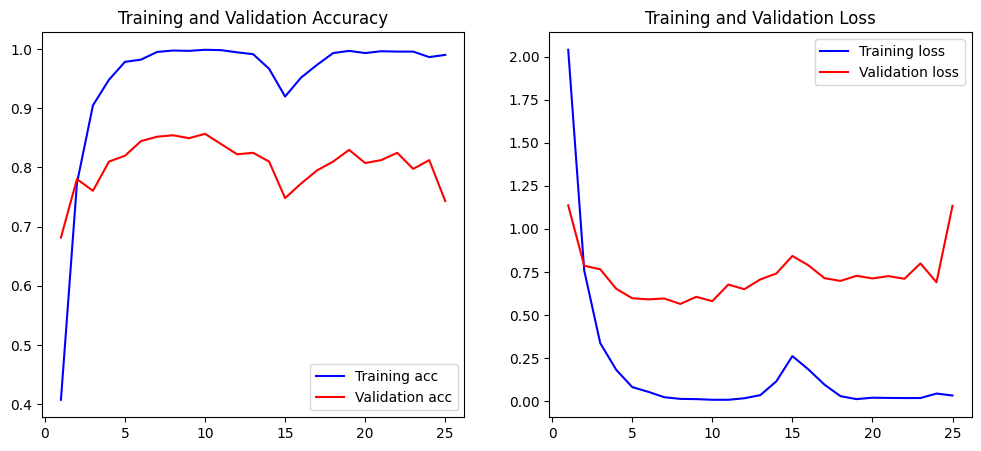


Classification Report:
              precision    recall  f1-score   support

     class_1       0.78      0.78      0.78         9
    class_10       0.57      0.67      0.62        12
    class_11       0.93      1.00      0.96        13
    class_12       0.75      0.71      0.73        17
    class_13       1.00      1.00      1.00        21
    class_14       0.75      1.00      0.86        12
    class_15       0.67      0.71      0.69        14
    class_16       0.50      0.55      0.52        11
    class_17       1.00      1.00      1.00        12
    class_18       1.00      0.94      0.97        16
    class_19       1.00      1.00      1.00         8
     class_2       0.80      0.73      0.76        11
    class_20       0.87      0.68      0.76        19
    class_21       0.93      0.93      0.93        15
    class_22       0.93      1.00      0.97        14
    class_23       0.88      0.88      0.88        16
    class_24       0.94      0.89      0.91        18
   

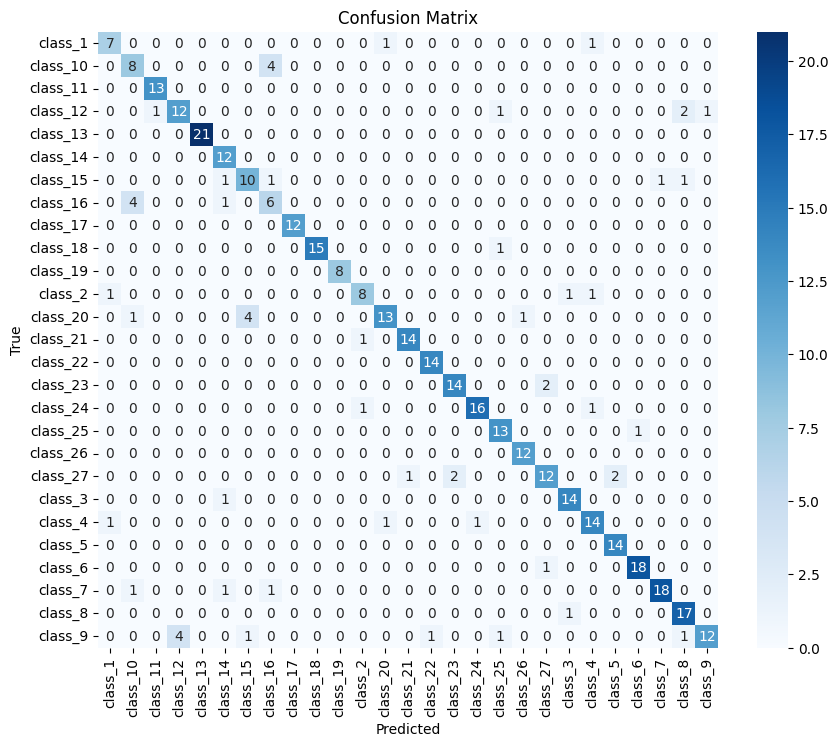

Model saved to deit_mel_spectrogram.pth


In [4]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = '/kaggle/working/organized_images'  # Path to your dataset folder
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMG_SIZE = 224
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# DeiT expects 224x224 RGB images.
# If your spectrograms are grayscale, .convert('RGB') handles it automatically.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(), # Optional: depends if time-inversion makes sense for your audio
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

def load_data(data_dir):
    # Check if directory exists
    if not os.path.exists(data_dir):
        # CREATE DUMMY DATA FOR DEMONSTRATION (If you don't have data yet)
        print(f"Data directory '{data_dir}' not found. Creating dummy data...")
        os.makedirs(data_dir, exist_ok=True)
        classes = ['class_A', 'class_B', 'class_C']
        for cls in classes:
            os.makedirs(os.path.join(data_dir, cls), exist_ok=True)
            for i in range(20): # 20 images per class
                # Create random noise image simulating a spectrogram
                img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
                plt.imsave(os.path.join(data_dir, cls, f'spec_{i}.png'), img)
    
    # Use ImageFolder. Expected structure:
    # root/
    #   class_1/
    #     img1.png
    #   class_2/
    #     img2.png
    full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
    
    # Split into Train (80%) and Validation (20%)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Apply validation transforms to validation set
    val_dataset.dataset.transform = data_transforms['val']

    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    }
    
    class_names = full_dataset.classes
    return dataloaders, class_names

# ==========================================
# 3. MODEL SETUP (DeiT)
# ==========================================
def initialize_model(num_classes):
    # Load pretrained DeiT tiny model
    # 'deit_tiny_patch16_224' is efficient. Use 'deit_small_patch16_224' for higher accuracy.
    print("Loading pretrained DeiT model...")
    model = timm.create_model('deit_small_patch16_224', pretrained=True)
    
    # Modify the classification head (DeiT head is usually named 'head')
    n_inputs = model.head.in_features
    model.head = nn.Linear(n_inputs, num_classes)
    
    return model.to(DEVICE)

# ==========================================
# 4. TRAINING LOOPS
# ==========================================
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    since = time.time()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Store history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Deep copy the model if it's the best one
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# ==========================================
# 5. VISUALIZATION & EVALUATION
# ==========================================
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

def evaluate_performance(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# ==========================================
# 6. MAIN EXECUTION
# ==========================================
if __name__ == '__main__':
    # 1. Load Data
    dataloaders, class_names = load_data(DATA_DIR)
    print(f"Classes found: {class_names}")
    
    # 2. Initialize Model
    model = initialize_model(len(class_names))
    
    # 3. Define Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    # AdamW is often preferred for Transformers
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    
    # 4. Train
    model, history = train_model(model, dataloaders, criterion, optimizer, num_epochs=NUM_EPOCHS)
    
    # 5. Plot Results
    plot_training_history(history)
    
    # 6. Detailed Evaluation
    evaluate_performance(model, dataloaders['val'], class_names)
    
    # 7. Save Model
    torch.save(model.state_dict(), 'deit_mel_spectrogram.pth')
    print("Model saved to deit_mel_spectrogram.pth")